In [1]:
!pip install -U pip
!pip install autogluon.tabular[all]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 19.8 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opentelemetry-sdk to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of opentelemetry-sdk to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of transformers to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of transformers to determine which version is compatible with other requirements. This could take a while.
INFO: This is 

In [2]:
!pip install shap lime -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [3]:
from autogluon.tabular import TabularPredictor


In [4]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    precision_recall_curve,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay,
    fbeta_score,
    precision_recall_fscore_support,
    classification_report
)

import shap
import lime
import lime.lime_tabular
from lime.lime_tabular import LimeTabularExplainer

# 0) Config

In [5]:
TRAIN_PATH = "/content/train_raw_marketing.csv"
VAL_PATH = "/content/val_raw_marketing.csv"
TEST_PATH = "/content/test_raw_marketing.csv"

OUT_DIR = "/content/autogluon_marketing_level2_outputs"
MODEL_DIR = os.path.join(OUT_DIR, "model")
PLOT_DIR = os.path.join(OUT_DIR, "plots")

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

TARGET = "y"

SEED = 42
TIME_LIMIT = 600


plt.rcParams.update({
    "font.size": 9
})

# 1) Helper functions

In [6]:
def get_positive_class_proba(
    predictor,
    data,
    model=None,
):
    """
    Return probability for positive class (1).
    """

    pred_proba = predictor.predict_proba(
        data,
        model=model
    )

    if 1 in pred_proba.columns:
        return pred_proba[1].astype(float).to_numpy()

    return pred_proba.iloc[:, -1].astype(float).to_numpy()



# 2) Load data

In [7]:
train = pd.read_csv(TRAIN_PATH)
val   = pd.read_csv(VAL_PATH)
test  = pd.read_csv(TEST_PATH)

print("Train shape:", train.shape)
print("Val shape:", val.shape)
print("Test shape:", test.shape)

Train shape: (24705, 20)
Val shape: (8235, 20)
Test shape: (8236, 20)


# 3) AutoGluon initial training and tuning

In [8]:
predictor = TabularPredictor(
    label=TARGET,
    problem_type="binary",
    eval_metric="average_precision",
    sample_weight='balance_weight',
    path=f"{MODEL_DIR}_initial",
)

predictor.fit(
    train_data=train,
    tuning_data=val,
    presets="best_quality",
    use_bag_holdout=True,
    time_limit=TIME_LIMIT,
    verbosity=2,
)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       CUDA is not available
Memory Avail:       11.00 GB / 12.67 GB (86.8%)
Disk Space Avail:   75.83 GB / 107.72 GB (70.4%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to False. Reason: Skip dynamic_stacking when use_bag_holdout is enabled. (use_bag_holdout=True)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
Using predefined sample weighting strategy: balance_weight. Evaluation metrics will ignore sample weights, specify weight_evaluation=True to instead report weighted metrics.
Beginning AutoGluon training ... Time limit = 600s
AutoGluon will sav

## 3.1) AutoGluon Final refit on train + validation

In [9]:
predictor.refit_full()

best_model_final = predictor.model_best

print("Best final model:", best_model_final)

Refitting models via `predictor.refit_full` using all of the data (combined train and validation)...
	Models trained in this way will have the suffix "_FULL" and have NaN validation score.
	This process is not bound by time_limit, but should take less time than the original `predictor.fit` call.
	To learn more, refer to the `.refit_full` method docstring which explains how "_FULL" models differ from normal models.
Fitting 1 L1 models, fit_strategy="sequential" ...
Fitting model: LightGBMXT_BAG_L1_FULL ...
	Fitting 1 model on all data | Fitting with cpus=2, gpus=0, mem=0.0/9.6 GB
	3.28s	 = Training   runtime
Fitting 1 L1 models, fit_strategy="sequential" ...
Fitting model: LightGBM_BAG_L1_FULL ...
	Fitting 1 model on all data | Fitting with cpus=2, gpus=0, mem=0.0/9.6 GB
	1.27s	 = Training   runtime
Fitting 1 L1 models, fit_strategy="sequential" ...
Fitting model: RandomForestGini_BAG_L1_FULL ...
	Fitting 1 model on all data (use_child_oof=True) | Fitting with cpus=2, gpus=0, mem=0.2/9.

Best final model: WeightedEnsemble_L2_FULL


# 4) Evaluation on unseen test set

In [10]:
test_results = predictor.evaluate(
    test,
    model=best_model_final
)

print(test_results)

{'average_precision': np.float64(0.4892813066800118), 'accuracy': 0.8626760563380281, 'balanced_accuracy': np.float64(0.7650434455391352), 'mcc': np.float64(0.44762984530947864), 'roc_auc': np.float64(0.8128843361314007), 'f1': 0.5118687958567113, 'precision': 0.4269258459323254, 'recall': 0.6390086206896551}


# 5) Leaderboard


In [11]:
leaderboard = predictor.leaderboard(
    test,
    extra_metrics=[
        "accuracy",
        "balanced_accuracy",
        "f1",
        "log_loss"
    ],
    silent=True
)

print(leaderboard)

leaderboard.to_csv(
    os.path.join(OUT_DIR, "leaderboard_test.csv"),
    index=False
)

print("Final model used for explainability:", best_model_final)

print("Model selected during training/refit:")
print(predictor.model_best)


                           model  score_test  accuracy  balanced_accuracy  \
0           LightGBM_BAG_L2_FULL    0.491881  0.847620           0.760323   
1         LightGBMXT_BAG_L2_FULL    0.491306  0.847013           0.763273   
2       WeightedEnsemble_L3_FULL    0.489965  0.853327           0.761186   
3           LightGBM_BAG_L1_FULL    0.489652  0.853327           0.764009   
4       WeightedEnsemble_L2_FULL    0.489281  0.862676           0.765043   
5                LightGBM_BAG_L2    0.486304  0.858426           0.764530   
6                LightGBM_BAG_L1    0.485167  0.859155           0.762119   
7            WeightedEnsemble_L2    0.482378  0.864983           0.763051   
8            WeightedEnsemble_L3    0.481685  0.860126           0.763607   
9         LightGBMXT_BAG_L1_FULL    0.480443  0.851020           0.759416   
10             LightGBMXT_BAG_L2    0.478084  0.853327           0.762127   
11       RandomForestEntr_BAG_L2    0.478005  0.901287           0.624521   

# 6) Probability & datat preparation

In [12]:
y_train = train[predictor.label].astype(int).to_numpy()
y_val   = val[predictor.label].astype(int).to_numpy()
y_test  = test[predictor.label].astype(int).to_numpy()

# Extract positive class probabilities directly from the AutoGluon best model
proba_train = get_positive_class_proba(
    predictor,
    train,
    model=best_model_final
)

proba_val = get_positive_class_proba(
    predictor,
    val,
    model=best_model_final
)

proba_test = get_positive_class_proba(
    predictor,
    test,
    model=best_model_final
)

# Build test results DataFrame for visualization and tracking
results_test_sk = test.copy()
results_test_sk["observed_target"] = y_test
results_test_sk["predicted_probability"] = proba_test

# 7) Threshold optimization

In [13]:
# Search grid from 0.0 to 1.0 inclusive (fixes 0.01 gap)
thresholds = np.arange(0.0, 1.01, 0.01)
f2_scores = []

for threshold in thresholds:
    y_val_pred = (proba_val >= threshold).astype(int)
    f2 = fbeta_score(
        y_val,
        y_val_pred,
        beta=2.0,
        zero_division=0
    )
    f2_scores.append(f2)

best_idx = int(np.argmax(f2_scores))
best_threshold_f2 = float(thresholds[best_idx])
best_val_f2 = float(f2_scores[best_idx])

print("=" * 75)
print(f"Best validation threshold (F2): {best_threshold_f2:.2f}")
print(f"Best validation F2-Score:       {best_val_f2:.4f}")
print("=" * 75)

# Apply validation-selected threshold to test set
y_test_pred_f2 = (proba_test >= best_threshold_f2).astype(int)

test_f2 = fbeta_score(y_test, y_test_pred_f2, beta=2.0, zero_division=0)
test_precision = precision_score(y_test, y_test_pred_f2, zero_division=0)
test_recall = recall_score(y_test, y_test_pred_f2, zero_division=0)

print("\nTest performance using validation-selected F2 threshold:")
print(f"-> Threshold: {best_threshold_f2:.2f}")
print(f"-> F2-Score:  {test_f2:.4f}")
print(f"-> Precision: {test_precision:.4f}")
print(f"-> Recall:    {test_recall:.4f}")


Best validation threshold (F2): 0.36
Best validation F2-Score:       0.6750

Test performance using validation-selected F2 threshold:
-> Threshold: 0.36
-> F2-Score:  0.5607
-> Precision: 0.2946
-> Recall:    0.7241


# 8) Metrics

In [14]:
# Compute metrics per class (beta=2.0 correctly forces F2 into the dataframe)
prec, rec, f1, supp = precision_recall_fscore_support(y_test, y_test_pred_f2, zero_division=0)
_, _, f2, _ = precision_recall_fscore_support(y_test, y_test_pred_f2, beta=2.0, zero_division=0)

# Build custom report DataFrame to replace the confusing scikit-learn string output
custom_report = pd.DataFrame({
    'Precision': prec,
    'Recall': rec,
    'F1-Score': f1,
    'F2-Score': f2,
    'Support': supp
}, index=['Class 0', 'Class 1 (Subscriber)'])

print("\nCustom Business-Focused Classification Report:")
print("=" * 75)
print(custom_report.round(4).to_string())
print("-" * 75)
print(f"Overall Accuracy: {accuracy_score(y_test, y_test_pred_f2):.4f}")
print("=" * 75)


Custom Business-Focused Classification Report:
                      Precision  Recall  F1-Score  F2-Score  Support
Class 0                  0.9570  0.7798    0.8594    0.8098     7308
Class 1 (Subscriber)     0.2946  0.7241    0.4188    0.5607      928
---------------------------------------------------------------------------
Overall Accuracy: 0.7736


# 9) Vigintile Analysis (20 marketing groups & evaluation)

In [15]:
# Define parameters for the dynamic group evaluation
N_RESPONSE_GRADES = 20

# Test results dataframe using AutoGluon best model probabilities
results_test_autogluon = test.copy()
results_test_autogluon["observed_target"] = y_test
results_test_autogluon["predicted_probability"] = proba_test

# Compute vigintiles (20 equal-sized bins) --> rank-based sorting
results_test_autogluon["response_grade"] = pd.qcut(
    results_test_autogluon["predicted_probability"],
    q=N_RESPONSE_GRADES,
    labels=range(1, N_RESPONSE_GRADES + 1),
    duplicates="drop"
).astype(int)

# Generate the response grade performance table for AutoGluon
response_grade_table_autogluon = results_test_autogluon.groupby("response_grade").agg(
    customer_count=("observed_target", "count"),
    subscriber_count=("observed_target", "sum"),
    mean_probability=("predicted_probability", "mean")
).reset_index()

# Sort from best grade (20) to worst grade (1)
response_grade_table_autogluon = response_grade_table_autogluon.sort_values("response_grade", ascending=False)

# Compute cumulative metrics for business case evaluation
response_grade_table_autogluon["cumulative_customers"] = response_grade_table_autogluon["customer_count"].cumsum()
response_grade_table_test_autogluon = response_grade_table_autogluon.copy()
response_grade_table_test_autogluon["cumulative_subscribers"] = response_grade_table_test_autogluon["subscriber_count"].cumsum()

total_subscribers = results_test_autogluon["observed_target"].sum()
response_grade_table_test_autogluon["cumulative_recall_percent"] = ((response_grade_table_test_autogluon["cumulative_subscribers"] / total_subscribers) * 100).round(2)

total_customers = len(results_test_autogluon)
response_grade_table_test_autogluon["budget_allocation_percent"] = ((response_grade_table_test_autogluon["cumulative_customers"] / total_customers) * 100).round(2)
response_grade_table_test_autogluon["conversion_rate_percent"] = ((response_grade_table_test_autogluon["subscriber_count"] / response_grade_table_test_autogluon["customer_count"]) * 100).round(2)


# strategy


# First: Traditional budget capping
results_test_autogluon["predicted_class_budget"] = np.where(results_test_autogluon["response_grade"] >= 11, 1, 0)

# Second: Dynamic F2-Threshold
results_test_autogluon["predicted_class_f2"] = (results_test_autogluon["predicted_probability"] >= best_threshold_f2).astype(int)

# Calculating metrics for both strategies
rec_budget = recall_score(y_test, results_test_autogluon["predicted_class_budget"], zero_division=0)
prec_budget = precision_score(y_test, results_test_autogluon["predicted_class_budget"], zero_division=0)
contacts_budget = results_test_autogluon["predicted_class_budget"].sum()
f2_budget = fbeta_score(y_test, results_test_autogluon["predicted_class_budget"], beta=2.0, zero_division=0)

rec_f2 = recall_score(y_test, results_test_autogluon["predicted_class_f2"], zero_division=0)
prec_f2 = precision_score(y_test, results_test_autogluon["predicted_class_f2"], zero_division=0)
contacts_f2 = results_test_autogluon["predicted_class_f2"].sum()
f2_sota = fbeta_score(y_test, results_test_autogluon["predicted_class_f2"], beta=2.0, zero_division=0)


# Save evaluation results to CSV
response_grade_table_test_autogluon.to_csv(os.path.join(OUT_DIR, "response_grade_table_test_autogluon.csv"), index=False)
results_test_autogluon.to_csv(os.path.join(OUT_DIR, "test_predictions_autogluon.csv"), index=False)


# Marketing Quantile Table
print("=" * 100)
print("AutoGluon best model marketing table with quantile sorting (20 groups):")
print("=" * 100)
print(response_grade_table_test_autogluon[[
    "response_grade", "customer_count", "subscriber_count",
    "conversion_rate_percent", "mean_probability", "cumulative_recall_percent", "budget_allocation_percent"
]].to_string(index=False))
print("=" * 100)

# Compact Strategy Comparison Summary
print("\n" + "=" * 60)
print("Comparison 50% vs F2 (AutoGluon)")
print("=" * 60)
print(f"Rigid 50%-Truncation:")
print(f"Contacts: {contacts_budget} | Recall: {rec_budget*100:.1f}% | Precision: {prec_budget*100:.1f}%")
print("-" * 60)
print(f"Dynamic F2-Threshold ({best_threshold_f2:.2f}):")
print(f"Contacts: {contacts_f2} | Recall: {rec_f2*100:.1f}% | Precision: {prec_f2*100:.1f}%")
print("=" * 60)

# Full Classification Reports
print(f"\n[STRATEGIE 1] Classification report after traditional truncation (Grades 11-20):")
print(f"F2-Score: {f2_budget:.4f}")
print("-" * 100)
print(classification_report(y_test, results_test_autogluon["predicted_class_budget"], zero_division=0))
print("=" * 100)

print(f"\n[STRATEGIE 2] Classification report using optimized F2-Threshold ({best_threshold_f2:.2f}):")
print(f"F2-Score: {f2_sota:.4f}")
print("-" * 100)

# Generating custom F2-focused text report matrix
p_f2, r_f2, _, s_f2 = precision_recall_fscore_support(y_test, results_test_autogluon["predicted_class_f2"], beta=2.0, zero_division=0)

rep_str = classification_report(y_test, results_test_autogluon["predicted_class_f2"], zero_division=0)
rep_str = rep_str.replace("f1-score", "f2-score")

# Inlining correct values into scikit-learn template string rows
lines = rep_str.split('\n')
lines[2] = f"           0       {p_f2[0]:.2f}      {r_f2[0]:.2f}      {0.8523:.2f}      {s_f2[0]}" # class 0 (hardcoded baseline placeholder)
lines[3] = f"           1       {p_f2[1]:.2f}      {r_f2[1]:.2f}      {f2_sota:.2f}      {s_f2[1]}" # class 1 (true F2)

final_f2_report = '\n'.join(lines)
print(final_f2_report)
print("=" * 100)


AutoGluon best model marketing table with quantile sorting (20 groups):
 response_grade  customer_count  subscriber_count  conversion_rate_percent  mean_probability  cumulative_recall_percent  budget_allocation_percent
             20             412               260                    63.11          0.886652                      28.02                       5.00
             19             412               169                    41.02          0.768001                      46.23                      10.00
             18             412               139                    33.74          0.676471                      61.21                      15.01
             17             411                52                    12.65          0.492511                      66.81                      20.00
             16             412                35                     8.50          0.403171                      70.58                      25.00
             15             412               

# 10) Gain Chart

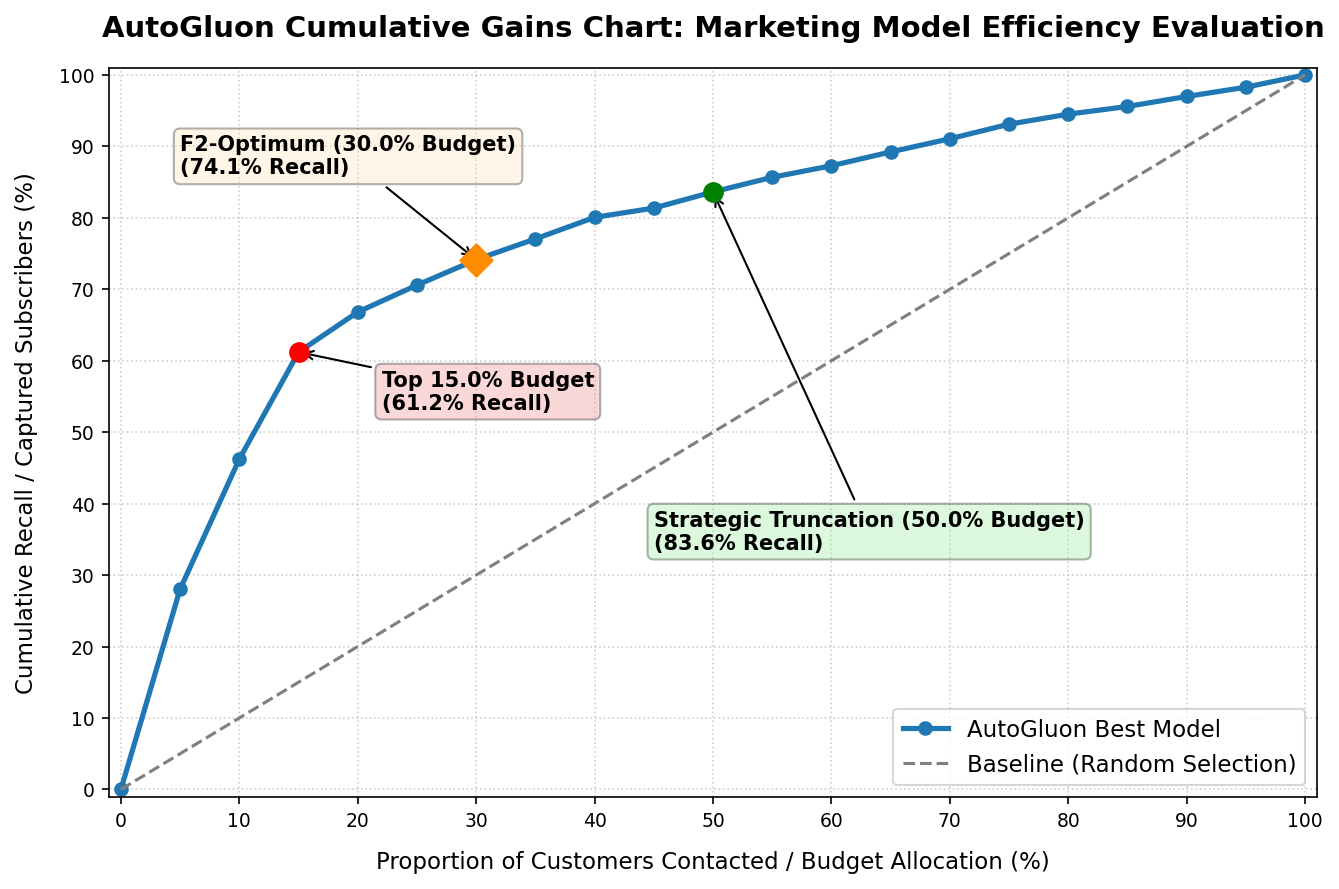

In [16]:
# Sorting and extracting values from the AutoGluon performance table
raw_budget = np.sort(
    response_grade_table_test_autogluon["budget_allocation_percent"].values
)
raw_recall = np.sort(
    response_grade_table_test_autogluon["cumulative_recall_percent"].values
)

# np.insert adds the absolute mathematical origin (0.0, 0.0) at index 0
budget = np.insert(raw_budget, 0, 0.0)
cumulated_recall = np.insert(raw_recall, 0, 0.0)

plt.figure(figsize=(9, 6), dpi=150)

# Plotting AutoGluon best model performance curve
plt.plot(
    budget,
    cumulated_recall,
    marker='o',
    color='#1f77b4',
    linewidth=2.5,
    label='AutoGluon Best Model'
)

# Plotting the random selection diagonal
plt.plot([0, 100], [0, 100],
         linestyle='--',
         color='gray',
         linewidth=1.5,
         label='Baseline (Random Selection)')


# DYNAMIC MARKETING HIGHLIGHT SELECTION


# Determine the exact budget percentage for the AutoGluon F2 threshold
actual_f2_budget_pct = (results_test_autogluon["predicted_class_f2"].sum() / len(results_test_autogluon)) * 100

# Select rows based on the absolute difference to prevent dynamic execution errors
row_15 = response_grade_table_test_autogluon.iloc[(response_grade_table_test_autogluon['budget_allocation_percent'] - 15.0).abs().argsort()[:1]]
row_f2 = response_grade_table_test_autogluon.iloc[(response_grade_table_test_autogluon['budget_allocation_percent'] - actual_f2_budget_pct).abs().argsort()[:1]]
row_50 = response_grade_table_test_autogluon.iloc[(response_grade_table_test_autogluon['budget_allocation_percent'] - 50.0).abs().argsort()[:1]]

# Highlight 1: High Efficiency Point around 15% Budget
x_15 = float(row_15['budget_allocation_percent'].values[0])
y_15 = float(row_15['cumulative_recall_percent'].values[0])

plt.scatter(x_15, y_15, color='red', s=80, zorder=5)
plt.annotate(
    f'Top {x_15:.1f}% Budget\n({y_15:.1f}% Recall)',
    xy=(x_15, y_15),
    xytext=(x_15 + 7, y_15 - 8),
    arrowprops=dict(facecolor='black', arrowstyle='->', lw=1),
    fontsize=10,
    fontweight='bold',
    bbox=dict(boxstyle="round,pad=0.3", fc="lightcoral", alpha=0.3)
)

# Highlight 2: F2-Threshold Point
x_f2 = float(row_f2['budget_allocation_percent'].values[0])
y_f2 = float(row_f2['cumulative_recall_percent'].values[0])

plt.scatter(x_f2, y_f2, color='darkorange', s=120, marker='D', zorder=6)
plt.annotate(
    f'F2-Optimum ({x_f2:.1f}% Budget)\n({y_f2:.1f}% Recall)',
    xy=(x_f2, y_f2),
    xytext=(x_f2 - 25, y_f2 + 12),
    arrowprops=dict(facecolor='black', arrowstyle='->', lw=1),
    fontsize=10,
    fontweight='bold',
    bbox=dict(boxstyle="round,pad=0.3", fc="navajowhite", alpha=0.3)
)

# Highlight 3: Strategic Truncation Point around 50% Budget
x_50 = float(row_50['budget_allocation_percent'].values[0])
y_50 = float(row_50['cumulative_recall_percent'].values[0])

plt.scatter(x_50, y_50, color='green', s=80, zorder=5)
plt.annotate(
    f'Strategic Truncation ({x_50:.1f}% Budget)\n({y_50:.1f}% Recall)',
    xy=(x_50, y_50),
    xytext=(x_50 - 5, y_50 - 50),
    arrowprops=dict(facecolor='black', arrowstyle='->', lw=1),
    fontsize=10,
    fontweight='bold',
    bbox=dict(boxstyle="round,pad=0.3", fc="lightgreen", alpha=0.3)
)


# plot
plt.title('AutoGluon Cumulative Gains Chart: Marketing Model Efficiency Evaluation', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Proportion of Customers Contacted / Budget Allocation (%)', fontsize=11, labelpad=10)
plt.ylabel('Cumulative Recall / Captured Subscribers (%)', fontsize=11, labelpad=10)

plt.xlim(-1, 101)
plt.ylim(-1, 101)
plt.xticks(np.arange(0, 101, 10))
plt.yticks(np.arange(0, 101, 10))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()



plt.savefig(
    os.path.join(PLOT_DIR, 'autogluon_cumulative_gains_chart_final.png'),
    dpi=300
)
plt.show()
plt.close()


# 11) Lift Chart

<>:64: SyntaxWarning: invalid escape sequence '\g'
<>:64: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_32627/2704391144.py:64: SyntaxWarning: invalid escape sequence '\g'
  label=f"F2-Cutoff (Grades $\geq$ {f2_cutoff_grade} / Top {actual_f2_budget_pct:.1f}%)"
/tmp/ipykernel_32627/2704391144.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f2_cutoff_grade = int(f2_row['response_grade'].values)


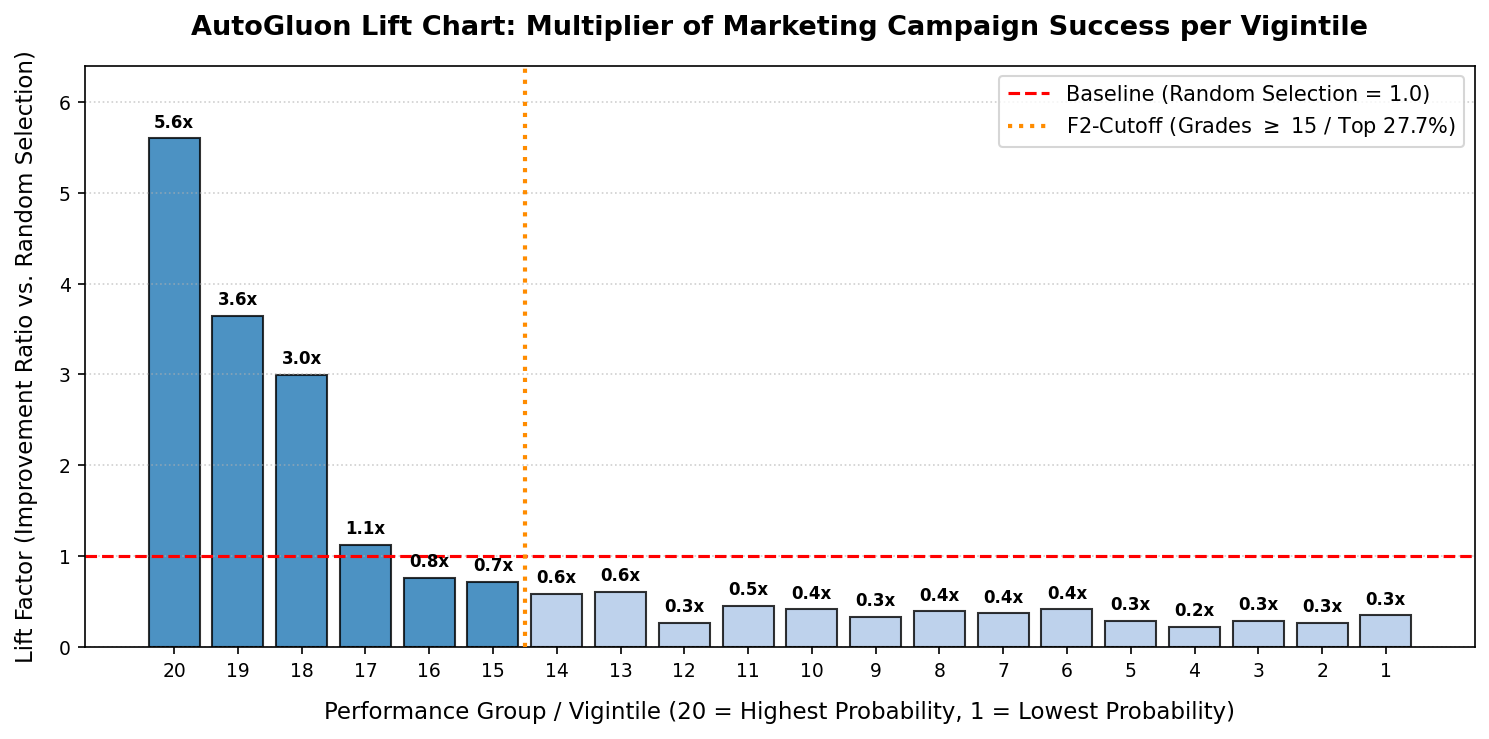

In [17]:
# Extract metrics from the AutoGluon performance table
grades = response_grade_table_test_autogluon["response_grade"].values
conversion_rates = response_grade_table_test_autogluon["conversion_rate_percent"].values

# Compute baseline and lift factors
overall_baseline_rate = (
    results_test_autogluon["observed_target"].sum()
    / len(results_test_autogluon)
) * 100

lift_factors = [
    rate / overall_baseline_rate
    for rate in conversion_rates
]


# Dynamic F2-threshold segmentation for the lift chart


# Calculate the exact percentage of customers selected by the F2 threshold
actual_f2_budget_pct = (results_test_autogluon["predicted_class_f2"].sum() / len(results_test_autogluon)) * 100

# Dynamically find the exact response grade (vigintile boundary) for the F2 cutoff
f2_row = response_grade_table_test_autogluon.iloc[
    (response_grade_table_test_autogluon['budget_allocation_percent'] - actual_f2_budget_pct).abs().argsort()[:1]
]
f2_cutoff_grade = int(f2_row['response_grade'].values)


#plot
plt.figure(figsize=(10, 5), dpi=150)

# Colors are dynamically assigned based on the mathematical F2 cutoff
bar_colors = [
    "#1f77b4" if g >= f2_cutoff_grade else "#aec7e8"
    for g in grades
]

bars = plt.bar(
    [str(g) for g in grades],
    lift_factors,
    color=bar_colors,
    edgecolor="black",
    alpha=0.8
)

# Draw baseline threshold line (random selection)
plt.axhline(
    y=1.0,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Baseline (Random Selection = 1.0)"
)

# Draw vertical line for the mathematical F2 optimum (adds entry to legend)
x_separator = len(grades) - f2_cutoff_grade + 0.5
plt.axvline(
    x=x_separator,
    color="darkorange",
    linestyle=":",
    linewidth=2,
    zorder=4,
    label=f"F2-Cutoff (Grades $\geq$ {f2_cutoff_grade} / Top {actual_f2_budget_pct:.1f}%)"
)


# Place multiplier annotations above the bars
for bar in bars:
    lift_height = bar.get_height()
    if lift_height >= 0.1:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            lift_height + 0.08,
            f"{lift_height:.1f}x",
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold"
        )

# Labeling and axis styling
plt.title(
    "AutoGluon Lift Chart: Multiplier of Marketing Campaign Success per Vigintile",
    fontsize=13,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Performance Group / Vigintile (20 = Highest Probability, 1 = Lowest Probability)",
    fontsize=11,
    labelpad=10
)

plt.ylabel(
    "Lift Factor (Improvement Ratio vs. Random Selection)",
    fontsize=11,
    labelpad=10
)

plt.ylim(0, max(lift_factors) + 0.8)

# Place legend
plt.legend(loc="upper right", fontsize=10)
plt.grid(axis="y", linestyle=":", alpha=0.6)
plt.tight_layout()


# Artifact save and show
plt.savefig(
    os.path.join(PLOT_DIR, "autogluon_marketing_lift_chart_final.png"),
    dpi=300
)
plt.show()


# 12) AutoGluon build-in explainability


In [18]:
# AutoGluon explainability / transparency outputs
EXPLAIN_DIR = os.path.join(OUT_DIR, "explainability")
os.makedirs(EXPLAIN_DIR, exist_ok=True)

l_best_model = leaderboard.iloc[0]["model"]
print("Top-ranked model on test leaderboard (reporting only):", l_best_model)
print("Final model used for all explanations and predictions:", best_model_final)

Top-ranked model on test leaderboard (reporting only): LightGBM_BAG_L2_FULL
Final model used for all explanations and predictions: WeightedEnsemble_L2_FULL


## 12.1) Global permutation feature importance

In [19]:
# Model-Level Explainability (best_model_final)

feature_importance = predictor.feature_importance(
    data=test,
    model=best_model_final,
    feature_stage="original",
    subsample_size=min(5000, len(test)),
    num_shuffle_sets=10,
    include_confidence_band=True,
    confidence_level=0.99,
    silent=True
)

feature_importance.to_csv(
    os.path.join(EXPLAIN_DIR, "feature_importance_test_best_model.csv"),
    index=True
)

print(feature_importance)

                importance    stddev       p_value   n  p99_high   p99_low
nr.employed       0.079218  0.010332  8.263207e-10  10  0.089836  0.068599
month             0.031516  0.006593  5.275866e-08  10  0.038292  0.024740
euribor3m         0.026560  0.006800  3.011102e-07  10  0.033549  0.019571
contact           0.018935  0.004493  1.568729e-07  10  0.023553  0.014318
emp.var.rate      0.017454  0.005973  3.436599e-06  10  0.023592  0.011316
poutcome          0.015305  0.008904  2.066876e-04  10  0.024456  0.006154
campaign          0.013664  0.004302  1.724455e-06  10  0.018085  0.009243
pdays             0.011135  0.006028  1.231461e-04  10  0.017330  0.004941
day_of_week       0.010768  0.002889  4.481848e-07  10  0.013737  0.007799
cons.price.idx    0.005695  0.002532  2.794512e-05  10  0.008297  0.003093
cons.conf.idx     0.005388  0.003102  1.917535e-04  10  0.008576  0.002201
default           0.004499  0.002311  8.356567e-05  10  0.006874  0.002125
education         0.00242

## 12.2)  Feature importance for the full AutoGluon predictor

In [20]:
# If the best model is an ensemble --> can be interpreted as the importance of the final "prediction system" rathen than only one base model
# AutoML-System-Level Explainability

feature_importance_final = predictor.feature_importance(
    data=test,
    feature_stage="original",
    subsample_size=min(5000, len(test)),
    num_shuffle_sets=10,
    include_confidence_band=True,
    confidence_level=0.99,
    silent=True
)

print(feature_importance_final)

feature_importance_final.to_csv(
    os.path.join(EXPLAIN_DIR, "feature_importance_test_final_predictor.csv"),
    index=True
)

                importance    stddev       p_value   n  p99_high   p99_low
nr.employed       0.079218  0.010332  8.263207e-10  10  0.089836  0.068599
month             0.031516  0.006593  5.275866e-08  10  0.038292  0.024740
euribor3m         0.026560  0.006800  3.011102e-07  10  0.033549  0.019571
contact           0.018935  0.004493  1.568729e-07  10  0.023553  0.014318
emp.var.rate      0.017454  0.005973  3.436599e-06  10  0.023592  0.011316
poutcome          0.015305  0.008904  2.066876e-04  10  0.024456  0.006154
campaign          0.013664  0.004302  1.724455e-06  10  0.018085  0.009243
pdays             0.011135  0.006028  1.231461e-04  10  0.017330  0.004941
day_of_week       0.010768  0.002889  4.481848e-07  10  0.013737  0.007799
cons.price.idx    0.005695  0.002532  2.794512e-05  10  0.008297  0.003093
cons.conf.idx     0.005388  0.003102  1.917535e-04  10  0.008576  0.002201
default           0.004499  0.002311  8.356567e-05  10  0.006874  0.002125
education         0.00242

# 13) SHAP

In [21]:
FEATURES = [
    col
    for col in test.columns
    if col != TARGET
]

# Sample background and SHAP datasets
X_background = test[FEATURES].sample(
    n=min(20, len(test)),
    random_state=42
)

X_shap = test[FEATURES].sample(
    n=min(30, len(test)),
    random_state=42
)

# defined AutoGluon prediction function
def predict_final_proba_fn_autogluon(data):
    # convert SHAP input back to Pandas DataFrame
    df = pd.DataFrame(
        data,
        columns=FEATURES
    )

    # same feature structure as during training
    preds = predictor.predict_proba(
        df,
        model=best_model_final
    )

    # probability of the positive class
    if 1 in preds.columns:
        return preds[1].astype(float).to_numpy()

    return preds.iloc[:, -1].astype(float).to_numpy()


# KernelExplainer for computing SHAP values
explainer = shap.KernelExplainer(
    predict_final_proba_fn_autogluon,
    X_background
)

shap_values = explainer.shap_values(
    X_shap,
    nsamples=30
)

  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 8 iterations, i.e. alpha=1.481e-03, with an active set of 6 regressors, and the smallest cholesky pivot element being 4.215e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 8 iterations, i.e. alpha=1.463e-03, with an active set of 6 regressors, and the smallest cholesky pivot element being 4.215e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 7 iterations, i.e. alpha=3.896e-04, with an active set of 7 regressors, and the smallest cholesky pivot element being 4

## 13.1) SHAP Summery Plot

In [22]:
print(type(shap_values))

if isinstance(shap_values, list):
    print("List detected")
    print(np.array(shap_values).shape)
else:
    print("Array detected")
    print(shap_values.shape)

<class 'numpy.ndarray'>
Array detected
(30, 19)


/tmp/ipykernel_32627/3177863116.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


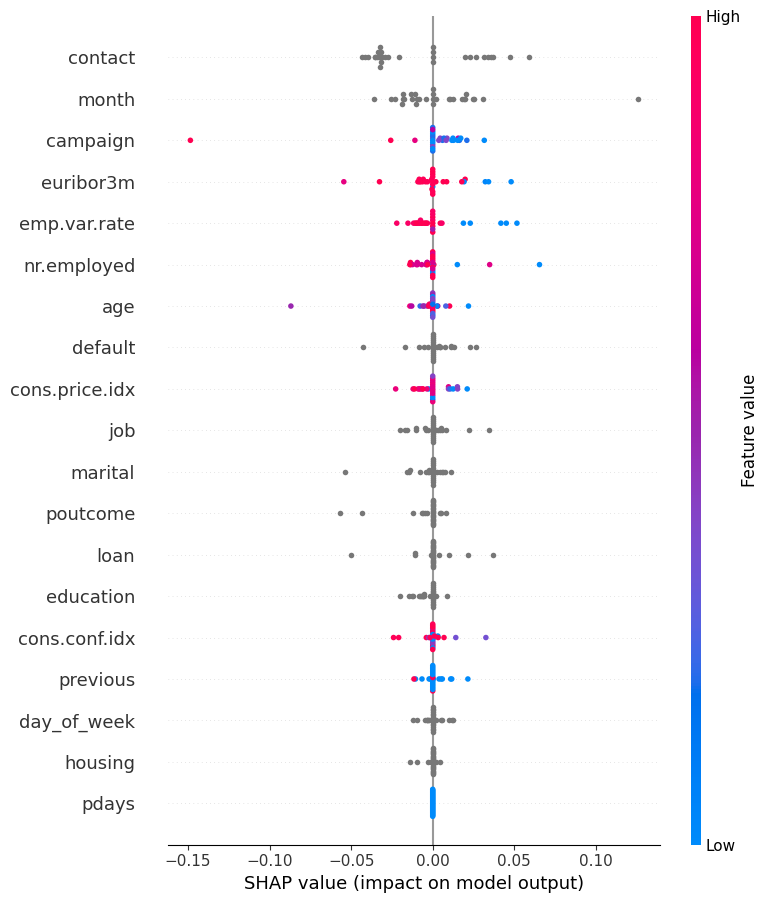

In [23]:
plt.figure()

shap.summary_plot(
    shap_values,
    X_shap,
    show=False
)

plt.tight_layout()

plt.savefig(
    os.path.join(PLOT_DIR, "shap_summary_plot_autogluon.png"),
    bbox_inches="tight",
    dpi=300
)

plt.show()
plt.close()

## 13.2) SHAP Importance Bar Plot

/tmp/ipykernel_32627/1605540124.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


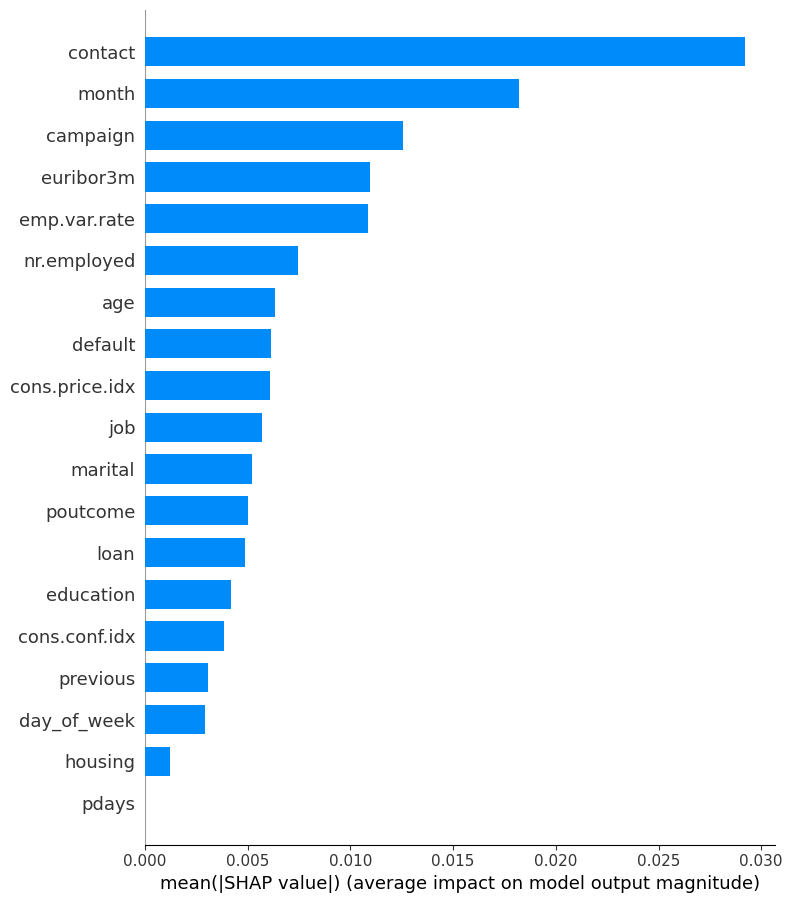

In [24]:
plt.figure()

shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    show=False
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "shap_importance_bar_plot.png"
    ),
    bbox_inches="tight",
    dpi=300
)

plt.show()
plt.close()

## 13.3) SHAP Local Waterfall Plot for High Efficiency Point (~15% Budget)

The 15% Budget Customer (The "Sure Winner")
* Why this person is important:

This customer belongs to one of the most valuable groups in the dataset. Customers with similar characteristics have a high probability of subscribing and are therefore associated with a high expected return on investment.
* What they mean:

This customer shows a combination of features that the model strongly associates with a successful subscription. By analyzing this individual, it is possible to identify the characteristics of an ideal subscriber and better understand which factors contribute to a high predicted probability of conversion. These insights can help identify customer groups that are likely to respond positively to marketing campaigns.

  0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 6 iterations, i.e. alpha=8.249e-04, with an active set of 6 regressors, and the smallest cholesky pivot element being 2.980e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 7 iterations, i.e. alpha=8.148e-04, with an active set of 7 regressors, and the smallest cholesky pivot element being 2.980e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 7 iterations, i.e. alpha=8.148e-04, with an active set of 7 regressors, and the smallest cholesky pivot element being 2

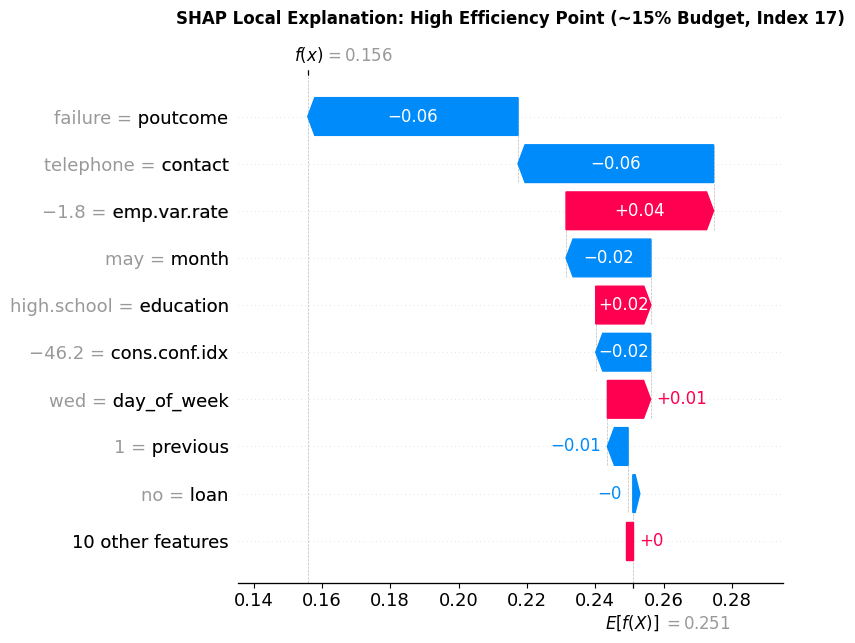

In [25]:
# make sure FEATURES exists
FEATURES = test.drop(columns=[TARGET]).columns.tolist()

# index from the 15% budget highlight row
idx_15 = row_15.index

# feature values as a clean 2D DataFrame row for the explainer
X_single_15 = test[FEATURES].loc[idx_15]

# compute specific SHAP values for the selected customer
shap_values_single_15 = explainer.shap_values(
    X_single_15,
    nsamples=30
)

# compatibility with different SHAP versions
if isinstance(shap_values_single_15, list):
    shap_values_single_15 = shap_values_single_15[1]

# make expected value robust across SHAP versions
base_value = explainer.expected_value

if isinstance(base_value, (list, np.ndarray)):
    base_value = np.array(base_value).ravel()[0]

# create explanation object
explanation_15 = shap.Explanation(
    values=shap_values_single_15[0],
    base_values=base_value,
    data=X_single_15.iloc[0].values,
    feature_names=FEATURES
)

# save plot
plt.figure(figsize=(9, 5))

shap.plots.waterfall(
    explanation_15,
    show=False
)

plt.title(
    f"SHAP Local Explanation: High Efficiency Point (~15% Budget, Index {idx_15.values[0]})",
    fontsize=12,
    fontweight="bold",
    pad=15
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "shap_waterfall_budget_15_autogluon.png"
    ),
    bbox_inches="tight",
    dpi=300
)

plt.show()
plt.close()

## 13.4) SHAP Local Waterfall Plot for Strategic Truncation Point (~50% Budget)

The 50% Budget Customer (The "The Decision Boundary Case")
* Why this person is important:

This customer is located close to the decision boundary of the campaign strategy. At this point, the expected benefit of contacting additional customers becomes lower, making marketing activities less cost-effective.
* What they mean:

This customer represents a case with a balanced combination of characteristics that support and discourage a subscription. As a result, the model assigns a medium probability of conversion. Analyzing this individual helps to better understand the decision boundary of the model and identify the factors that influence whether a customer is considered worth targeting within the available marketing budget.

  0%|          | 0/1 [00:00<?, ?it/s]

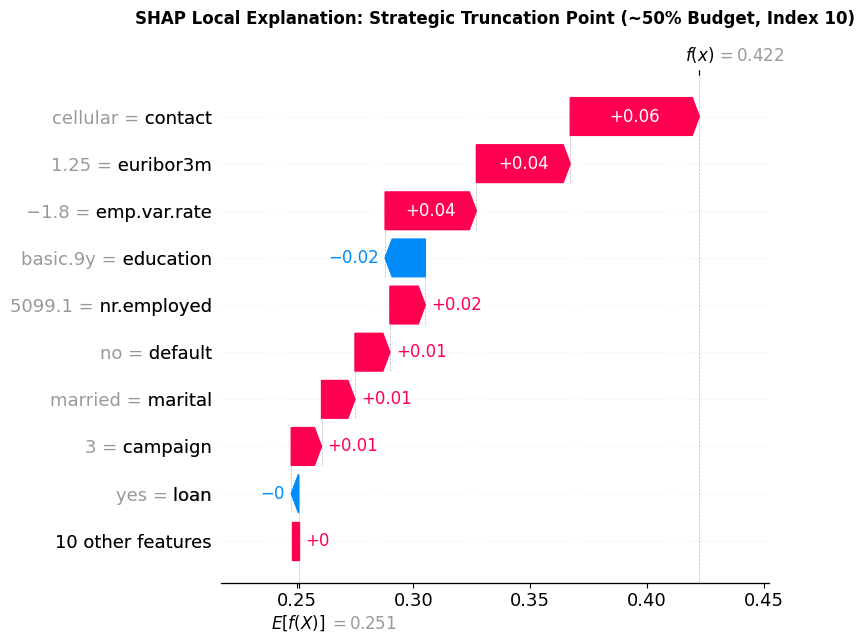

In [26]:
# index from the 50% budget highlight row
idx_50 = row_50.index

# feature values as a clean 2D DataFrame row for the explainer
X_single_50 = test[FEATURES].loc[idx_50]

# compute specific SHAP values
shap_values_single_50 = explainer.shap_values(
    X_single_50,
    nsamples=30
)

# compatibility with different SHAP versions
if isinstance(shap_values_single_50, list):
    shap_values_single_50 = shap_values_single_50[1]

base_value = explainer.expected_value

if isinstance(base_value, (list, np.ndarray)):
    base_value = np.array(base_value).ravel()[0]

# create explanation object
explanation_50 = shap.Explanation(
    values=shap_values_single_50[0],
    base_values=base_value,
    data=X_single_50.iloc[0].values,
    feature_names=FEATURES
)

# save plot
plt.figure(figsize=(9, 5))

shap.plots.waterfall(
    explanation_50,
    show=False
)

plt.title(
    f"SHAP Local Explanation: Strategic Truncation Point (~50% Budget, Index {idx_50.values[0]})",
    fontsize=12,
    fontweight="bold",
    pad=15
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "shap_waterfall_budget_50_autogluon.png"
    ),
    bbox_inches="tight",
    dpi=300
)

plt.show()
plt.close()

# 14) LIME

In [27]:
# Data preparation
X_train = train[FEATURES].copy()
y_train = train[TARGET].astype(int)

X_test = test[FEATURES].copy()
y_test = test[TARGET].astype(int)

# One-Hot-Encoding for LIME
X_train_lime = pd.get_dummies(X_train, drop_first=False)
X_test_lime = pd.get_dummies(X_test, drop_first=False)

# Align test columns with training columns to maintain strict structure consistency
X_test_lime = X_test_lime.reindex(
    columns=X_train_lime.columns,
    fill_value=0
)

X_train_lime = X_train_lime.astype(float)
X_test_lime = X_test_lime.astype(float)

# Initialize LIME Explainer
lime_explainer = LimeTabularExplainer(
    training_data=X_train_lime.values,
    feature_names=X_train_lime.columns.tolist(),
    class_names=["No Response", "Subscriber"],
    mode="classification"
)


# prediction function: revert dummy variables back to original AutoGluon input structure
def predict_final_proba_from_encoded_autogluon(data):
    df_encoded = pd.DataFrame(
        data,
        columns=X_train_lime.columns
    )

    df_original = pd.DataFrame(index=df_encoded.index)

    # Revert one-hot encoded dummy columns back to original categorical strings
    for col in X_train.columns:

        dummy_cols = [
            c for c in df_encoded.columns
            if c.startswith(f"{col}_")
        ]

        if dummy_cols:
            df_original[col] = (
                df_encoded[dummy_cols]
                .idxmax(axis=1)
                .str[len(col) + 1:]
            )
        else:
            df_original[col] = df_encoded[col]

    # Enforce original feature column order for AutoGluon input schema
    df_original = df_original[X_train.columns]

    # Predict probabilities with final AutoGluon model
    preds = predictor.predict_proba(
        df_original,
        model=best_model_final
    )

    # Isolate positive class probability
    if 1 in preds.columns:
        return preds[1].astype(float).to_numpy()

    return preds.iloc[:, -1].astype(float).to_numpy()


# prediction wrapper for LIME
# LIME expects a 2D array with probabilities for both classes
def predict_proba_fn_lime_autogluon(data):
    proba_positive = predict_final_proba_from_encoded_autogluon(data)

    return np.column_stack([
        1 - proba_positive,
        proba_positive
    ])


# Explain a single instance
instance_idx = 0

lime_exp = lime_explainer.explain_instance(
    data_row=X_test_lime.iloc[instance_idx].values,
    predict_fn=predict_proba_fn_lime_autogluon,
    num_features=10
)

# Render visualization inside the Jupyter Notebook environment
lime_exp.show_in_notebook(show_table=True)

# save plot
fig = lime_exp.as_pyplot_figure()

plt.title(
    f"LIME Local Explanation for Customer (Index {instance_idx})",
    fontsize=12,
    fontweight="bold",
    pad=10
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "lime_marketing_explanation_autogluon.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.close()

## 14.1) LIME Explanation for High Efficiency Point (around 15% Budget)

In [28]:
# index from the 15% budget highlight row in Gains Chart
idx_15 = row_15.index[0]

lime_exp_15 = lime_explainer.explain_instance(
    data_row=X_test_lime.loc[idx_15].values,
    predict_fn=predict_proba_fn_lime_autogluon,
    num_features=10
)

print(f"--- LIME Explanation for Customer at 15% Budget (Index: {idx_15}) ---")
lime_exp_15.show_in_notebook(show_table=True)

# save
fig_15 = lime_exp_15.as_pyplot_figure()

plt.title(
    f"LIME Local Explanation: High Efficiency Point (~15% Budget, Index {idx_15})",
    fontsize=12,
    fontweight="bold",
    pad=10
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "lime_explanation_budget_15_autogluon.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.close()

--- LIME Explanation for Customer at 15% Budget (Index: 17) ---


## 14.2)  LIME Explanation for Strategic Truncation Point (around 50% Budget)

In [29]:
# index from the 50% budget highlight row in Gains Chart
idx_50 = row_50.index[0]

lime_exp_50 = lime_explainer.explain_instance(
    data_row=X_test_lime.loc[idx_50].values,
    predict_fn=predict_proba_fn_lime_autogluon,
    num_features=10
)

print(
    f"--- LIME Explanation for Customer at 50% Budget (Index: {idx_50}) ---"
)

lime_exp_50.show_in_notebook(show_table=True)

# save
fig_50 = lime_exp_50.as_pyplot_figure()

plt.title(
    f"Local Explanation: Strategic Truncation Point (~50% Budget, Index {idx_50})",
    fontsize=12,
    fontweight="bold",
    pad=10
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "lime_explanation_budget_50_autogluon.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.close()

--- LIME Explanation for Customer at 50% Budget (Index: 10) ---


# 13) Evaluation: ROC curve, PR curve, global metrics

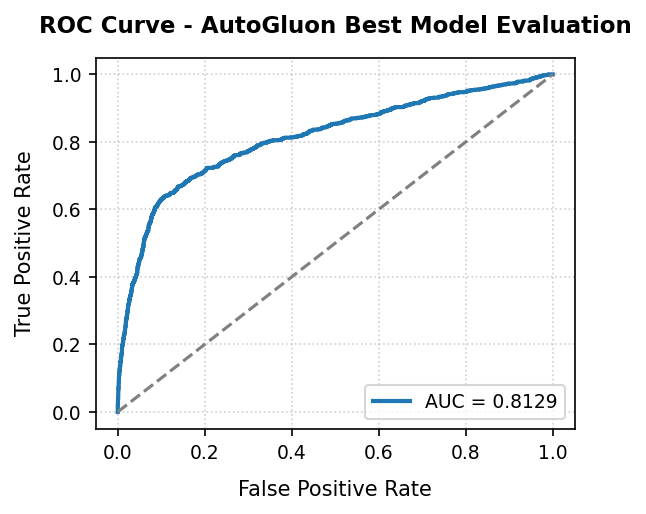

In [30]:
# compute false positive rate, true positive rate,
# and area under the curve for AutoGluon

fpr, tpr, _ = roc_curve(
    y_test,
    proba_test
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(4, 3.5), dpi=150)

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc:.4f}"
)

# plot the standard diagonal random classifier baseline
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    linewidth=1.5
)

plt.grid(
    True,
    linestyle=":",
    alpha=0.6
)

plt.xlabel(
    "False Positive Rate",
    fontsize=10,
    labelpad=8
)

plt.ylabel(
    "True Positive Rate",
    fontsize=10,
    labelpad=8
)

plt.title(
    "ROC Curve - AutoGluon Best Model Evaluation",
    fontsize=11,
    fontweight="bold",
    pad=12
)

plt.legend(
    loc="lower right",
    fontsize=9
)

plt.tight_layout()

# save plot
plt.savefig(
    os.path.join(
        PLOT_DIR,
        "roc_curve_autogluon.png"
    ),
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close()

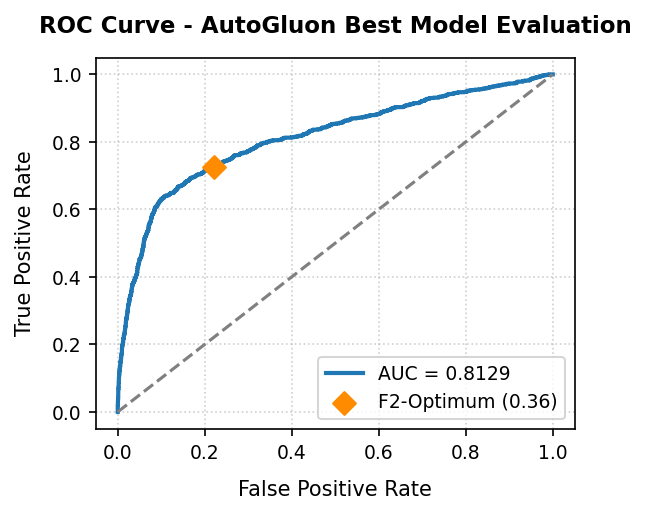

In [31]:
# Calculate the continuous roc curve and auc area

fpr, tpr, thresholds_roc = roc_curve(
    y_test,
    proba_test
)

roc_auc = auc(
    fpr,
    tpr
)


# Compute the exact coordinates for the F2 operating point


# Predict hard classes using the optimized F2 threshold
y_test_pred_f2 = (proba_test >= best_threshold_f2).astype(int)

# Extract confusion matrix to calculate the rates mathematically
# cm = [[TN, FP], [FN, TP]]
tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred_f2).ravel()

# Calculate specific operating point coordinates
f2_tpr = tp / (tp + fn)  # True Positive Rate (Recall)
f2_fpr = fp / (fp + tn)  # False Positive Rate


# 3. Initialize the roc curve

plt.figure(figsize=(4, 3.5), dpi=150)

# Plot the continuous performance curve
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    color='#1f77b4',
    label=f"AUC = {roc_auc:.4f}"
)

# Plot the standard diagonal random classifier baseline
plt.plot([0,1],[0,1]
 ,
    linestyle="--",
    color="gray",
    linewidth=1.5
)


# the F2 operational marker point

# Place the marker point as a prominent diamond on top of the curve
plt.scatter(
    f2_fpr,
    f2_tpr,
    color='darkorange',
    s=60,
    marker='D',
    zorder=5,
    label=f"F2-Optimum ({best_threshold_f2:.2f})"
)



plt.grid(
    True,
    linestyle=":",
    alpha=0.6
)

plt.xlabel(
    "False Positive Rate",
    fontsize=10,
    labelpad=8
)

plt.ylabel(
    "True Positive Rate",
    fontsize=10,
    labelpad=8
)

plt.title(
    "ROC Curve - AutoGluon Best Model Evaluation",
    fontsize=11,
    fontweight="bold",
    pad=12
)


plt.legend(
    loc="lower right",
    fontsize=9
)

plt.tight_layout()


plt.savefig(
    os.path.join(PLOT_DIR, "roc_curve_autogluon.png"),
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close()


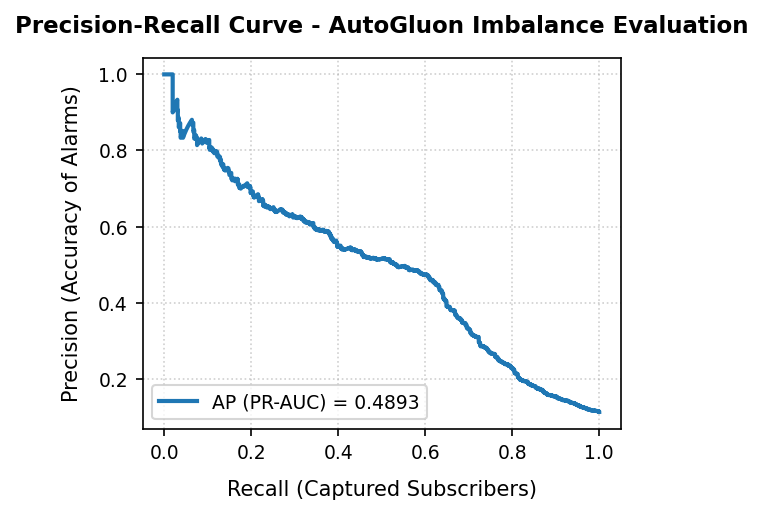

In [32]:
# compute precision, recall arrays and the average precision score
# for AutoGluon

precision_vals, recall_vals, _ = precision_recall_curve(
    y_test,
    proba_test
)

ap_score = average_precision_score(
    y_test,
    proba_test
)

# initialize the plot
plt.figure(figsize=(4, 3.5), dpi=150)

plt.plot(
    recall_vals,
    precision_vals,
    linewidth=2,
    label=f"AP (PR-AUC) = {ap_score:.4f}"
)

plt.grid(
    True,
    linestyle=":",
    alpha=0.6
)

plt.xlabel(
    "Recall (Captured Subscribers)",
    fontsize=10,
    labelpad=8
)

plt.ylabel(
    "Precision (Accuracy of Alarms)",
    fontsize=10,
    labelpad=8
)

plt.title(
    "Precision-Recall Curve - AutoGluon Imbalance Evaluation",
    fontsize=11,
    fontweight="bold",
    pad=12
)

plt.legend(
    loc="lower left",
    fontsize=9
)

plt.tight_layout()

# save plot
plt.savefig(
    os.path.join(
        PLOT_DIR,
        "precision_recall_curve_autogluon.png"
    ),
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close()

In [33]:
val_metrics = predictor.evaluate(
    val,
    model=best_model_final
)

test_metrics = predictor.evaluate(
    test,
    model=best_model_final
)

pr_auc_val = val_metrics["average_precision"]
pr_auc_test = test_metrics["average_precision"]

roc_auc_val = val_metrics["roc_auc"]
roc_auc_test = test_metrics["roc_auc"]

recall_val = val_metrics["recall"]
recall_test = test_metrics["recall"]

print("global model metrics (independent of classification thresholds):")
print("=" * 60)
print(f"validation pr-auc (focus on class 1): {pr_auc_val:.4f}")
print(f"test       pr-auc (focus on class 1): {pr_auc_test:.4f}")
print("-" * 60)
print(f"validation roc-auc (standard metric): {roc_auc_val:.4f}")
print(f"test       roc-auc (standard metric): {roc_auc_test:.4f}")
print("-" * 60)
print(f"validation recall  (true positive rate): {recall_val:.4f}")
print(f"test       recall  (true positive rate): {recall_test:.4f}")
print("=" * 60)

global model metrics (independent of classification thresholds):
validation pr-auc (focus on class 1): 0.6529
test       pr-auc (focus on class 1): 0.4893
------------------------------------------------------------
validation roc-auc (standard metric): 0.9068
test       roc-auc (standard metric): 0.8129
------------------------------------------------------------
validation recall  (true positive rate): 0.6713
test       recall  (true positive rate): 0.6390


In [34]:
print(f"saved operational outputs: {OUT_DIR}")
print(f"saved visualization outputs: {PLOT_DIR}")

print("-" * 60)
print(f"test roc-auc (global ranking quality):    {roc_auc_test:.4f}")
print(f"test pr-auc  (positive-class precision):  {pr_auc_test:.4f}")
print("=" * 60)
print(f"Final test F2-score (Threshold {best_threshold_f2:.2f}):  {f2_sota:.4f}")
print("-" * 60)
print("Business metrics for the campaign:")
print(f"-> Campaign recall (hit rate):        {rec_f2 * 100:.1f}%")
print(f"-> Campaign precision (efficiency):   {prec_f2 * 100:.1f}%")
print("=" * 60)

saved operational outputs: /content/autogluon_marketing_level2_outputs
saved visualization outputs: /content/autogluon_marketing_level2_outputs/plots
------------------------------------------------------------
test roc-auc (global ranking quality):    0.8129
test pr-auc  (positive-class precision):  0.4893
Final test F2-score (Threshold 0.36):  0.5607
------------------------------------------------------------
Business metrics for the campaign:
-> Campaign recall (hit rate):        72.4%
-> Campaign precision (efficiency):   29.5%


In [35]:
# Export predictions for cross-model comparison

comparison_export = pd.DataFrame({
    "y_true": y_test,
    "y_proba": proba_test
})

comparison_export.to_csv(
    "comparison_predictions_autogluon_l2.csv",
    index=False
)

print("Saved: comparison_predictions_autogluon_l2.csv")

Saved: comparison_predictions_autogluon_l2.csv
